# Does a stock's "beta" ever change?

**My question:** Apple's beta tells you how much it moves compared to the whole stock
market. If beta is 1.2, Apple tends to move 20% more than the market on a given day. I
wanted to know: is that number fixed, or does it change over time?

I'm using basic linear regression for this — the same `y = mx + b` idea from math class,
just applied to stock returns instead of x/y points. The slope of the line *is* beta.

**What I used:** pandas to handle the data, yfinance to download real stock prices,
matplotlib to make the charts, and scikit-learn's `LinearRegression` to fit the line.
I used AI assistance to help me write and debug this code (something my mentor and my
school both said is fine, as long as I understand what it's doing), and I've gone through
every part of it below so I can explain it myself.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.rcParams["figure.figsize"] = (10, 5)
print("libraries loaded")

libraries loaded


## Step 1: Try it the simple way — one stock, two years

I picked Apple (`AAPL`) as the stock and SPY (an ETF that tracks the S&P 500) as a
stand-in for "the market." I'm using daily **returns** (percent change from one day to
the next), not raw prices — because a stock's price barely moves day to day, so
regressing price-on-price gives a fake-looking perfect score that doesn't mean anything.
Returns actually vary, which is why beta is always calculated on returns.

In [2]:
prices = yf.download(["AAPL", "SPY"], period="2y", auto_adjust=True, progress=False)["Close"]
returns = prices.pct_change().dropna()
returns.columns = ["aapl_return", "spy_return"]
returns.tail()

,aapl_return,spy_return
Date,,
2026-09-09,-0.002783,-0.004648
2026-09-10,0.035612,-0.005994
2026-09-11,0.017454,0.008524
2026-09-14,0.002438,-0.004462
2026-09-15,-0.005224,-0.004587


## Step 2: Split into a training period and a test period

This is standard practice for any prediction model: fit the line on older data, then
check it against newer data it hasn't seen. I split by time (not randomly), since mixing
random days would let the model "peek" at the future.

In [3]:
X = returns[["spy_return"]]
y = returns["aapl_return"]

# Manual chronological split -- no shuffling, no imported helper. I just take the
# first 80% of days (in date order) as training and the last 20% as the test period,
# by slicing on row position. Since the DataFrame is already sorted by date, this is
# the same idea as scikit-learn's test_size=0.2, shuffle=False, done by hand.
split_point = int(len(returns) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

model = LinearRegression()
model.fit(X_train, y_train)
beta = model.coef_[0]

print(f"beta (the slope) = {beta:.2f}")
print(f"train R^2 = {r2_score(y_train, model.predict(X_train)):.2f}")
print(f"test R^2  = {r2_score(y_test, model.predict(X_test)):.2f}")

beta (the slope) = 1.19
train R^2 = 0.51
test R^2  = -0.16


**R² just means: what fraction of Apple's daily ups and downs does the market explain?**
1.0 would mean "perfectly," 0 would mean "not at all."

My training R² looked fine. But the test R² came back **negative** — which means on data
the model hadn't seen, it did *worse* than just guessing the average return every day.
That's not supposed to happen, and I didn't expect it. I could've just ignored it, but I
wanted to know if it was a fluke or something real, so I kept going instead.

## Step 3: Zoom out — does beta even stay the same over time?

Instead of one fixed beta, I recomputed it on a rolling 60-day window (about 3 months of
trading days), sliding forward one day at a time. That turns "beta" from a single number
into a line I can actually plot over time.

I also pulled 5 years of data instead of 2, so there's enough history to actually see a
pattern instead of judging off one weird stretch.

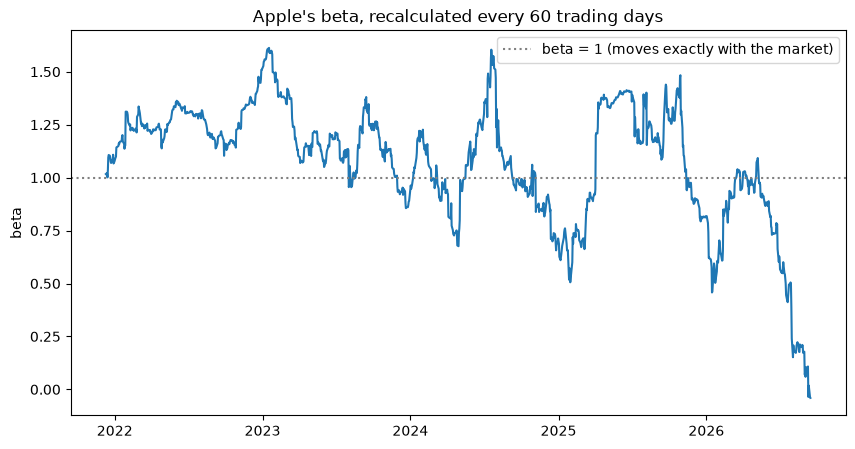

beta ranged from -0.04 to 1.61 over 5 years


In [4]:
prices_5y = yf.download(["AAPL", "SPY"], period="5y", auto_adjust=True, progress=False)["Close"]
returns_5y = prices_5y.pct_change().dropna()
returns_5y.columns = ["aapl_return", "spy_return"]

window = 60
rolling_cov = returns_5y["aapl_return"].rolling(window).cov(returns_5y["spy_return"])
rolling_var = returns_5y["spy_return"].rolling(window).var()
rolling_beta = (rolling_cov / rolling_var).dropna()

# beta = covariance / variance -- this is the same formula LinearRegression uses under
# the hood for a single predictor. I'm just recomputing it by hand on a moving window.

plt.plot(rolling_beta.index, rolling_beta.values)
plt.axhline(1.0, color="gray", linestyle=":", label="beta = 1 (moves exactly with the market)")
plt.title("Apple's beta, recalculated every 60 trading days")
plt.ylabel("beta")
plt.legend()
plt.show()

print(f"beta ranged from {rolling_beta.min():.2f} to {rolling_beta.max():.2f} over 5 years")

**This answers my original question: no, beta does not stay the same.** It moves around
constantly, and it clearly drops off a cliff toward the end of the chart. That out-of-sample
failure back in Step 2 wasn't a fluke — beta really was different in the more recent period.

## Step 4: Is this actually about Apple, or something bigger?

My first guess was "something happened to Apple specifically." Instead of just assuming
that, I tested it: I picked 10 more well-known stocks (Microsoft, Nvidia, Tesla, JPMorgan,
Exxon, Walmart, Coca-Cola, Procter & Gamble, Johnson & Johnson, NextEra) and checked
whether *their* betas also changed around the same time.

In [5]:
stocks = ["AAPL", "MSFT", "NVDA", "TSLA", "JPM", "XOM", "WMT", "KO", "PG", "JNJ", "NEE"]
prices_all = yf.download(stocks + ["SPY"], period="5y", auto_adjust=True, progress=False)["Close"]
returns_all = prices_all.pct_change().dropna()

# Splitting the 5 years roughly where the rolling beta chart above showed the drop.
break_date = "2025-10-28"
before = returns_all[returns_all.index < break_date]
after  = returns_all[returns_all.index >= break_date]

results = []
for stock in stocks:
    beta_before = LinearRegression().fit(before[[ "SPY"]], before[stock]).coef_[0]
    beta_after  = LinearRegression().fit(after[["SPY"]],  after[stock]).coef_[0]
    results.append({"stock": stock, "beta_before": beta_before, "beta_after": beta_after,
                     "change": beta_after - beta_before})

results = pd.DataFrame(results).sort_values("change")
print(results.round(2).to_string(index=False))

fell = (results["change"] < 0).sum()
print(f"\n{fell} out of {len(results)} stocks had their beta go DOWN over the same period.")

stock  beta_before  beta_after  change
  XOM         0.51       -0.66   -1.17
 AAPL         1.24        0.60   -0.64
   KO         0.31       -0.24   -0.55
  WMT         0.46       -0.06   -0.52
  NEE         0.58        0.12   -0.46
  JNJ         0.20       -0.20   -0.40
   PG         0.32       -0.02   -0.34
 NVDA         2.16        1.94   -0.22
 MSFT         1.15        0.97   -0.18
  JPM         0.89        0.77   -0.12
 TSLA         2.01        2.21    0.20

10 out of 11 stocks had their beta go DOWN over the same period.


**Not just Apple.** 10 of the 11 stocks I checked had their beta fall over the same
stretch. Whatever happened, it happened to the market broadly, not to one company.

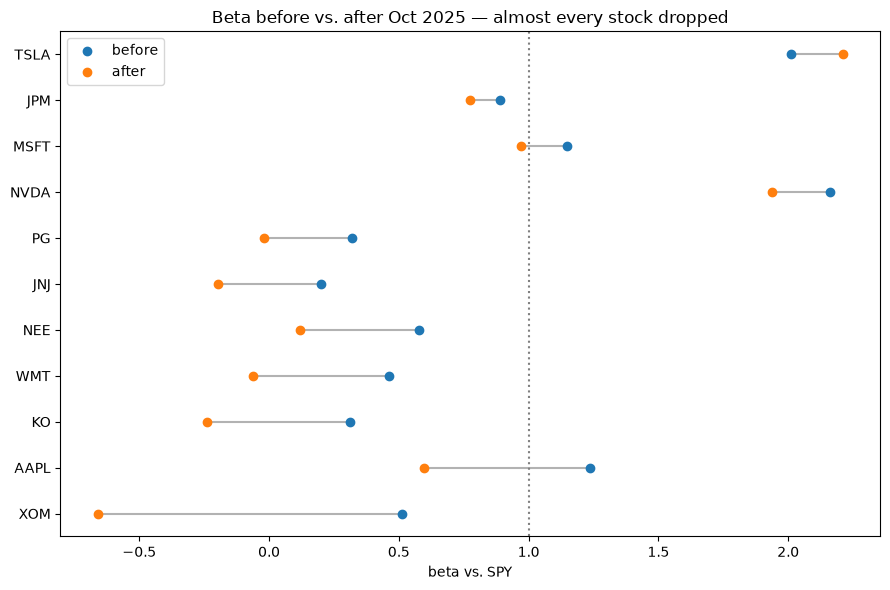

In [6]:
plt.figure(figsize=(9, 6))
order = results["stock"]
for i, row in enumerate(results.itertuples()):
    plt.plot([row.beta_before, row.beta_after], [i, i], color="gray", alpha=0.6)
    plt.scatter(row.beta_before, i, color="tab:blue", zorder=3, label="before" if i == 0 else "")
    plt.scatter(row.beta_after,  i, color="tab:orange", zorder=3, label="after" if i == 0 else "")
plt.yticks(range(len(order)), order)
plt.axvline(1.0, linestyle=":", color="gray")
plt.xlabel("beta vs. SPY")
plt.title("Beta before vs. after Oct 2025 — almost every stock dropped")
plt.legend()
plt.tight_layout()
plt.savefig("simple_fig1_before_after.png", dpi=120)
plt.show()

## Step 5: Ruling out my second guess

My next thought: maybe this is just because the S&P 500 (SPY) is weighted toward a
handful of huge tech companies, so "the market" doesn't really mean "stocks in general"
anymore. If that were true, I'd expect this effect to mostly disappear against an
**equal-weighted** version of the same 500 companies, called RSP — where a small company
counts just as much as Apple does.

In [7]:
prices_rsp = yf.download(["RSP"], period="5y", auto_adjust=True, progress=False)["Close"]
returns_all["RSP"] = prices_rsp["RSP"].pct_change()
returns_all = returns_all.dropna()
before_r = returns_all[returns_all.index < break_date]
after_r  = returns_all[returns_all.index >= break_date]

change_spy, change_rsp = [], []
for stock in stocks:
    b1 = LinearRegression().fit(before_r[["SPY"]], before_r[stock]).coef_[0]
    b2 = LinearRegression().fit(after_r[["SPY"]],  after_r[stock]).coef_[0]
    r1 = LinearRegression().fit(before_r[["RSP"]], before_r[stock]).coef_[0]
    r2 = LinearRegression().fit(after_r[["RSP"]],  after_r[stock]).coef_[0]
    change_spy.append(b2 - b1)
    change_rsp.append(r2 - r1)

print(f"average beta change vs SPY (cap-weighted)   : {np.mean(change_spy):+.2f}")
print(f"average beta change vs RSP (equal-weighted) : {np.mean(change_rsp):+.2f}")

average beta change vs SPY (cap-weighted)   : -0.40
average beta change vs RSP (equal-weighted) : -0.39


**Basically identical.** So it's not about a few giant companies dominating the index —
that guess didn't hold up, and I'm dropping it.

## Step 6: So what actually happened?

Beta is built from two ingredients: how closely a stock tracks the market
(**correlation**), and how much more the stock moves than the market
(**volatility ratio**). I checked which one changed.

In [8]:
corr_before = before_r[stocks].corr().values
corr_after  = after_r[stocks].corr().values
n = len(stocks)
avg_corr_before = corr_before[np.triu_indices(n, k=1)].mean()
avg_corr_after  = corr_after[np.triu_indices(n, k=1)].mean()

print(f"average correlation between the 11 stocks, before: {avg_corr_before:.2f}")
print(f"average correlation between the 11 stocks, after:  {avg_corr_after:.2f}")

average correlation between the 11 stocks, before: 0.25
average correlation between the 11 stocks, after:  0.06


**They stopped moving together.** The stocks used to rise and fall in sync with each
other about a quarter of the time (correlation ~0.25); afterward, that dropped to almost
nothing (~0.06). When stocks stop moving in sync with each other, they also stop moving
in sync with the market average, which pulls beta down. That's the actual mechanism —
not an Apple problem, not an index-weighting problem, just stocks trading more on their
own news instead of all reacting to the same market-wide moves.

## What I can actually say I found

1. Apple's beta is not a fixed number — it moves constantly, and it dropped sharply
   toward the end of my data.
2. That drop happened to 10 of 11 stocks I checked, not just Apple.
3. It's not caused by a few huge companies dominating the S&P 500 — I checked against an
   equal-weighted version of the index and got basically the same result.
4. The real cause: the stocks stopped moving together as much (their correlation with
   each other dropped a lot). Beta is partly built out of that correlation, so when it
   fell, beta fell with it, across almost every stock at once.

## What I can't say

- This doesn't predict anything — it only explains what already happened, using each
  day's own market move to explain that same day's stock move.
- I checked and this correlation drop, while real, isn't some record-breaking event — it's
  on the low end of normal, not something totally unprecedented.
- Apple is a big part of the S&P 500 itself, so some of this comes from Apple being part
  of the market I'm comparing it against, not two fully separate things.